In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Phase 1: Data Loading & Exploration

In [26]:
# Load the dataset
df = pd.read_csv(r"C:\Users\Rupali\OneDrive\Desktop\Divya\student_sales_data.csv")

In [27]:
df

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
0,TRX001,C001,John Smith,john@email.com,2024-01-15,Electronics,Laptop,1.0,999.99,999.99,Credit Card,USA,28.0,0.0
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3.0,29.99,89.97,PayPal,Canada,35.0,10.0
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10.0,5.99,NaN,Debit Card,USA,NaN,5.0
3,TRX004,C001,John Smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2.0,19.99,39.98,Credit Card,USA,28.0,0.0
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1.0,45.00,45.00,Credit Card,UK,42.0,15.0
5,TRX006,C005,Robert Brown,robert@email.com,2024-01-19,Electronics,Monitor,NaN,349.99,NaN,PayPal,USA,51.0,10.0
6,TRX007,C002,Sarah Johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1.0,79.99,79.99,Credit Card,Canada,35.0,20.0
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1.0,89.99,89.99,Debit Card,USA,29.0,0.0
8,TRX009,C007,David Lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2.0,149.99,299.98,Credit Card,USA,33.0,0.0
9,TRX010,C003,Mike Williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1.0,55.00,55.00,PayPal,USA,34.0,0.0


In [28]:
# Shape (rows, columns)

print(f"Row: {df.shape[0]} , column: {df.shape[1]}")

Row: 30 , column: 14


In [29]:
# Data types

print(df.dtypes)

transaction_id       object
customer_id          object
customer_name        object
email                object
purchase_date        object
product_category     object
product_name         object
quantity            float64
unit_price          float64
total_amount         object
payment_method       object
shipping_country     object
customer_age        float64
discount_percent    float64
dtype: object


In [30]:
# First few rows
df.head()

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
0,TRX001,C001,John Smith,john@email.com,2024-01-15,Electronics,Laptop,1.0,999.99,999.99,Credit Card,USA,28.0,0.0
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3.0,29.99,89.97,PayPal,Canada,35.0,10.0
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10.0,5.99,NaN,Debit Card,USA,NaN,5.0
3,TRX004,C001,John Smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2.0,19.99,39.98,Credit Card,USA,28.0,0.0
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1.0,45.00,45.00,Credit Card,UK,42.0,15.0


In [31]:
# last few rows
df.tail()

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0
29,TRX030,C025,Benjamin Martin,b.martin@email.com,2024-02-12,Electronics,Laptop,1.0,1299.99,-1299.99,Credit Card,USA,52.0,40.0


In [32]:
# Summary statistics
df.describe()

,quantity,unit_price,customer_age,discount_percent
count,28.000000,30.000000,29.000000,29.000000
mean,1.857143,180.858000,35.655172,8.344828
std,1.860193,284.858912,10.022389,10.219994
min,1.000000,5.990000,5.000000,0.000000
25%,1.000000,46.247500,29.000000,0.000000
50%,1.000000,74.990000,35.000000,5.000000
75%,2.000000,157.490000,42.000000,15.000000
max,10.000000,1299.990000,55.000000,40.000000


In [33]:
# Missing value counts

df.isnull().sum()

transaction_id      0
customer_id         0
customer_name       0
email               0
purchase_date       0
product_category    0
product_name        0
quantity            2
unit_price          0
total_amount        2
payment_method      0
shipping_country    0
customer_age        1
discount_percent    1
dtype: int64

## Phase 2: Data Cleaning

### **Handle Missing Values:**

In [57]:
df1 = df.copy()

In [62]:
# Fill missing quantity with 1

df1['quantity'] = df1['quantity'].fillna(1)

In [66]:
# Fill missing customer_age with median

df1["customer_age"] = df1['customer_age'].fillna(df1['customer_age'].median())

In [67]:
# Fill missing total_amount by calculation : quantity x unit_price

df1["total_amount"] = df1["total_amount"].fillna(df1["quantity"] * df1["unit_price"])

In [68]:
# or
df1['total_amount'] = df1.apply(
    lambda row: row['total_amount'] if pd.notna(row['total_amount']) else row['quantity'] * row['unit_price'],
    axis=1
)

In [69]:
# - Drop rows where critical information is completely missing

df1 = df1.dropna(subset=["customer_id", "product_name", "quantity", "unit_price"])

In [70]:
# or - Drop rows where critical information is completely missing
df1.dropna()

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
0,TRX001,C001,John Smith,john@email.com,2024-01-15,Electronics,Laptop,1.0,999.99,999.99,Credit Card,USA,28.0,0.0
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3.0,29.99,89.97,PayPal,Canada,35.0,10.0
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10.0,5.99,59.9,Debit Card,USA,35.0,5.0
3,TRX004,C001,John Smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2.0,19.99,39.98,Credit Card,USA,28.0,0.0
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1.0,45.00,45.00,Credit Card,UK,42.0,15.0
5,TRX006,C005,Robert Brown,robert@email.com,2024-01-19,Electronics,Monitor,1.0,349.99,349.99,PayPal,USA,51.0,10.0
6,TRX007,C002,Sarah Johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1.0,79.99,79.99,Credit Card,Canada,35.0,20.0
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1.0,89.99,89.99,Debit Card,USA,29.0,0.0
8,TRX009,C007,David Lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2.0,149.99,299.98,Credit Card,USA,33.0,0.0
9,TRX010,C003,Mike Williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1.0,55.00,55.00,PayPal,USA,34.0,0.0


In [71]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
0,TRX001,C001,John Smith,john@email.com,2024-01-15,Electronics,Laptop,1.0,999.99,999.99,Credit Card,USA,28.0,0.0
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3.0,29.99,89.97,PayPal,Canada,35.0,10.0
2,TRX003,C003,MIKE WILLIAMS,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10.0,5.99,59.9,Debit Card,USA,35.0,5.0
3,TRX004,C001,John Smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2.0,19.99,39.98,Credit Card,USA,28.0,0.0
4,TRX005,C004,emily chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1.0,45.00,45.00,Credit Card,UK,42.0,15.0
5,TRX006,C005,Robert Brown,robert@email.com,2024-01-19,Electronics,Monitor,1.0,349.99,349.99,PayPal,USA,51.0,10.0
6,TRX007,C002,Sarah Johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1.0,79.99,79.99,Credit Card,Canada,35.0,20.0
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1.0,89.99,89.99,Debit Card,USA,29.0,0.0
8,TRX009,C007,David Lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2.0,149.99,299.98,Credit Card,USA,33.0,0.0
9,TRX010,C003,Mike Williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1.0,55.00,55.00,PayPal,USA,34.0,0.0


### **Standardize Text Data:**

In [72]:
# - Convert all customer names to Title Case (consistent formatting)
df1["customer_name"] = df1["customer_name"].str.strip().str.title()

In [73]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
0,TRX001,C001,John Smith,john@email.com,2024-01-15,Electronics,Laptop,1.0,999.99,999.99,Credit Card,USA,28.0,0.0
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3.0,29.99,89.97,PayPal,Canada,35.0,10.0
2,TRX003,C003,Mike Williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10.0,5.99,59.9,Debit Card,USA,35.0,5.0
3,TRX004,C001,John Smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2.0,19.99,39.98,Credit Card,USA,28.0,0.0
4,TRX005,C004,Emily Chen,emily_c@email.com,2024-01-18,Books,Data Science 101,1.0,45.00,45.00,Credit Card,UK,42.0,15.0
5,TRX006,C005,Robert Brown,robert@email.com,2024-01-19,Electronics,Monitor,1.0,349.99,349.99,PayPal,USA,51.0,10.0
6,TRX007,C002,Sarah Johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1.0,79.99,79.99,Credit Card,Canada,35.0,20.0
7,TRX008,C006,Jessica Martinez,j.martinez@email.com,2024-01-21,Home,Coffee Maker,1.0,89.99,89.99,Debit Card,USA,29.0,0.0
8,TRX009,C007,David Lee,david.lee@hotmail.com,2024-01-22,Electronics,Headphones,2.0,149.99,299.98,Credit Card,USA,33.0,0.0
9,TRX010,C003,Mike Williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1.0,55.00,55.00,PayPal,USA,34.0,0.0


In [74]:
# - Convert emails to lowercase

df1["email"] = df1["email"].str.strip().str.lower()

In [75]:
# - Trim whitespace from all string columns

df1["product_category"] = df1["product_category"].str.strip()

In [76]:
df1["product_name"] = df1["product_name"].str.strip()

In [77]:
df1["shipping_country"] = df1["shipping_country"].str.strip()

###  **Fix Data Types:**

In [78]:
# Ensure all numeric columns (quantity, unit_price, total_amount, discount_percent, customer_age) are numeric
df1["quantity"]=df1['quantity'].astype(float)


In [ ]:
df1["total_amount"]=df1['total_amount'].astype(float)

In [80]:
# If the messy data is avaible

df1["total_amount"] = pd.to_numeric(df1["total_amount"],errors ="coerce")

In [81]:
df1["discount_percent"] = pd.to_numeric(df1["discount_percent"])

In [82]:
df1["customer_age"] = df1["customer_age"].astype(float)

In [83]:
df1["purchase_date"] = pd.to_datetime(df1["purchase_date"], errors="coerce")

In [84]:
#- Verify payment_method and product_category are strings

In [85]:
df1[["payment_method", "product_category"]].dtypes

payment_method      object
product_category    object
dtype: object

In [86]:
df1["payment_method"]= df1["payment_method"].astype("string")

In [87]:
df1["product_category"]= df1["product_category"].astype("string")

In [88]:
df1.dtypes

transaction_id              object
customer_id                 object
customer_name               object
email                       object
purchase_date       datetime64[ns]
product_category    string[python]
product_name                object
quantity                   float64
unit_price                 float64
total_amount               float64
payment_method      string[python]
shipping_country            object
customer_age               float64
discount_percent           float64
dtype: object

###  **Remove/Fix Duplicates:**

In [89]:
# Identify duplicate transactions (same transaction_id)

df1[df1.duplicated(subset="transaction_id")]

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent


In [90]:
# count the duplicate value in the column

df1["transaction_id"].duplicated().sum()

np.int64(0)

In [91]:
# Identify duplicate customers with slightly different names/emails

df1.groupby("customer_id")[["customer_name","email"]].nunique()


,customer_name,email
customer_id,,
C001,1,2
C002,1,4
C003,1,2
C004,1,1
C005,1,1
C006,1,1
C007,1,1
C008,1,1
C009,1,1


In [92]:
df1[df1.duplicated(subset="customer_name", keep=False)]

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
0,TRX001,C001,John Smith,john@email.com,2024-01-15,Electronics,Laptop,1.0,999.99,999.99,Credit Card,USA,28.0,0.0
1,TRX002,C002,Sarah Johnson,sarah.johnson@mail.com,2024-01-16,Books,Python Guide,3.0,29.99,89.97,PayPal,Canada,35.0,10.0
2,TRX003,C003,Mike Williams,mike@yahoo.com,2024-01-16,Electronics,USB Cable,10.0,5.99,59.90,Debit Card,USA,35.0,5.0
3,TRX004,C001,John Smith,john.smith@email.com,2024-01-17,Clothing,T-Shirt,2.0,19.99,39.98,Credit Card,USA,28.0,0.0
6,TRX007,C002,Sarah Johnson,sarah@email.com,2024-01-20,Clothing,Jeans,1.0,79.99,79.99,Credit Card,Canada,35.0,20.0
9,TRX010,C003,Mike Williams,mike.williams@email.com,2024-01-23,Books,The Art of Code,1.0,55.00,55.00,PayPal,USA,34.0,0.0
11,TRX012,C009,Christopher White,chris@email.com,2024-01-25,Electronics,Keyboard,1.0,99.99,99.99,Credit Card,Germany,45.0,5.0
13,TRX014,C002,Sarah Johnson,sarah.j@email.com,2024-01-27,Books,Machine Learning Basics,2.0,65.00,130.00,Debit Card,Canada,35.0,0.0
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0


In [93]:
df1["customer_name"].duplicated().sum()

np.int64(6)

In [94]:
df1[df1.duplicated(subset="email",keep =False)]

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent


In [95]:
df1["email"].duplicated().sum()

np.int64(0)

In [96]:
df1 = df1.sort_values(by="purchase_date", ascending=False)

In [97]:
# Keep only one record per duplicate (based on most recent date)

df1 = df1.sort_values("purchase_date", ascending=False).drop_duplicates("customer_id")

In [98]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent
29,TRX030,C025,Benjamin Martin,b.martin@email.com,2024-02-12,Electronics,Laptop,1.0,1299.99,-1299.99,Credit Card,USA,52.0,40.0
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0


### **Fix Invalid Data:**

In [99]:
# - Remove or fix rows with negative total_amount

df1 = df1[df1["total_amount"] >= 0]

In [100]:
# Remove rows with zero or negative quantity

df1 = df1[df1["quantity"] > 0]

In [101]:
# Remove rows with invalid discount percentages

df1 = df1[(df1["discount_percent"] >= 0) & (df1["discount_percent"] <= 100)] 

In [102]:
# Fix records where unit_price doesn't match total_amount / quantity

mask = (df1["total_amount"] - (df1["quantity"] * df1["unit_price"])).abs() > 0.01

df1.loc[mask, "total_amount"] = df1["quantity"] * df1["unit_price"]

In [103]:
df1["unit_price"] = df1["total_amount"] / df1["quantity"]

In [104]:

print(f"Rows:{df1.shape[0]}, Column:{df1.shape[1]}")

Rows:23, Column:14


## PHASE 3: FEATURE ENGINEERING

###  **Create New Columns:**

In [105]:
# `net_amount`: total_amount after applying discount

df1["net_amount"] = df1["total_amount"] - (df1["discount_percent"]/100)

# or this formula if the value in the percentage
#df1["net_amount"] = df1["total_amount"] * (1 - df1["discount_percent"] / 100)

In [106]:
# `year_month`: Extract year-month from purchase_date

df1["year_month"] = df1["purchase_date"].dt.to_period("M")


In [107]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02


In [108]:
# customer_segment`: Categorize customers as:
# "High Value" if total spending > $500

In [109]:
total_spend = df1.groupby("customer_id")["net_amount"].sum()

In [110]:
total_spend

customer_id
C001     39.98
C002     54.80
C003     55.00
C004     44.85
C005    349.89
C006     89.99
C007    299.98
C008    179.85
C009     99.94
C010    129.74
C011    349.99
C012    299.84
C013     39.89
C014     69.98
C016     89.99
C017     74.97
C018    199.89
C019    129.74
C020     49.99
C021    349.94
C022    139.83
C023    159.99
C024     59.99
Name: net_amount, dtype: float64

In [111]:
df1["customer_segment"] = df1.groupby("customer_id")["net_amount"].transform("sum").apply(
    lambda x: "High Value" if x > 500 else "Regular"
)

In [112]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month,customer_segment
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02,Regular
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02,Regular
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02,Regular
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02,Regular
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02,Regular
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02,Regular
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02,Regular
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02,Regular
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02,Regular
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02,Regular


In [113]:
# - `customer_segment`: Categorize customers as:
# - "High Value" if total spending > $500
# - "Medium Value" if total spending $100-$500
# - "Low Value" if total spending < $100
df1["Customer_segment1"] = df1.groupby("customer_id")["net_amount"].transform("sum").apply(
     lambda x:"High Value" if x > 500 else("Medium value" if x >=100 else "Low Value"))


In [114]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month,customer_segment,Customer_segment1
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02,Regular,Low Value
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02,Regular,Medium value
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02,Regular,Medium value
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02,Regular,Medium value
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02,Regular,Low Value
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02,Regular,Medium value
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02,Regular,Medium value
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02,Regular,Low Value
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02,Regular,Low Value
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02,Regular,Low Value


In [115]:
df1 = df1.drop(columns = "customer_segment")

In [ ]:
df1 = df1.drop(columns = "Customer_segment")

In [116]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month,Customer_segment1
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02,Low Value
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02,Medium value
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02,Medium value
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02,Medium value
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02,Low Value
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02,Medium value
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02,Medium value
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02,Low Value
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02,Low Value
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02,Low Value


### 10. **Add Derived Features:**

In [117]:
# - `discount_amount`: Calculate actual discount amount in dollars
df1["Actual_discount"] = df1["total_amount"] * (df1["discount_percent"] / 100)

In [118]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month,Customer_segment1,Actual_discount
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02,Low Value,0.0000
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02,Medium value,0.0000
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02,Medium value,20.9970
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02,Medium value,17.4995
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02,Low Value,0.0000
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02,Medium value,32.4975
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02,Medium value,19.9990
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02,Low Value,0.0000
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02,Low Value,11.0000
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02,Low Value,0.0000


In [119]:
# `purchase_quarter`: Extract quarter from purchase_date
df1["purchase_quarter"] = df1["purchase_date"].dt.quarter

In [120]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month,Customer_segment1,Actual_discount,purchase_quarter
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02,Low Value,0.0000,1
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02,Medium value,0.0000,1
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02,Medium value,20.9970,1
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02,Medium value,17.4995,1
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02,Low Value,0.0000,1
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02,Medium value,32.4975,1
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02,Medium value,19.9990,1
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02,Low Value,0.0000,1
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02,Low Value,11.0000,1
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02,Low Value,0.0000,1


In [121]:
df1.shape

(23, 19)

In [122]:
#  `is_repeat_customer`: Boolean indicating if customer has multiple purchases

df1["is_repeat_customer"]  = df1.groupby("customer_id")["transaction_id"].transform("count") > 1

In [123]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month,Customer_segment1,Actual_discount,purchase_quarter,is_repeat_customer
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02,Low Value,0.0000,1,False
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02,Medium value,0.0000,1,False
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02,Medium value,20.9970,1,False
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02,Medium value,17.4995,1,False
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02,Low Value,0.0000,1,False
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02,Medium value,32.4975,1,False
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02,Medium value,19.9990,1,False
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02,Low Value,0.0000,1,False
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02,Low Value,11.0000,1,False
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02,Low Value,0.0000,1,False


In [124]:
df1.shape

(23, 20)

## **Phase 4: Data Analysis & Insights**

### 11. **Descriptive Statistics:**

In [125]:
# - Average transaction amount

df1["total_amount"].mean()

np.float64(146.07478260869564)

In [126]:
df1.groupby("customer_id")["net_amount"].mean()

customer_id
C001     39.98
C002     54.80
C003     55.00
C004     44.85
C005    349.89
C006     89.99
C007    299.98
C008    179.85
C009     99.94
C010    129.74
C011    349.99
C012    299.84
C013     39.89
C014     69.98
C016     89.99
C017     74.97
C018    199.89
C019    129.74
C020     49.99
C021    349.94
C022    139.83
C023    159.99
C024     59.99
Name: net_amount, dtype: float64

In [127]:
# Median discount percentage

df1["discount_percent"].median()

5.0

In [128]:
# - Most popular product category

df1["product_category"].value_counts()

product_category
Books          6
Clothing       6
Electronics    6
Home           5
Name: count, dtype: Int64

In [129]:
# - Most common payment method

df1["payment_method"].value_counts()

payment_method
Credit Card    13
PayPal          7
Debit Card      3
Name: count, dtype: Int64

In [130]:
df1["payment_method"].value_counts().idxmax()

'Credit Card'

In [131]:
# Customer age statistics

df1["customer_age"].describe()

count    23.000000
mean     36.695652
std       8.314471
min      26.000000
25%      30.000000
50%      35.000000
75%      42.000000
max      55.000000
Name: customer_age, dtype: float64

### 12. **Customer Analysis:**

In [132]:
# Total number of unique customers

In [133]:
df1["customer_id"].nunique()

23

In [134]:
total_customers = df1["customer_id"].nunique()

In [135]:
total_customers

23

In [136]:
#  - Customer spending by segment

df1.groupby("Customer_segment1")["net_amount"].sum()

Customer_segment1
Low Value        769.37
Medium value    2588.68
Name: net_amount, dtype: float64

In [137]:
df1.groupby("Customer_segment1")["net_amount"].mean()

Customer_segment1
Low Value        64.114167
Medium value    235.334545
Name: net_amount, dtype: float64

In [138]:
df1["Customer_segment1"].value_counts()

Customer_segment1
Low Value       12
Medium value    11
Name: count, dtype: int64

In [140]:
df1.groupby("Customer_segment1")["net_amount"].agg(["sum", "mean", "count"])

,sum,mean,count
Customer_segment1,,,
Low Value,769.37,64.114167,12
Medium value,2588.68,235.334545,11


In [141]:
# Repeat customers (customers with 2+ transactions)

df1["customer_id"].value_counts() >= 2

customer_id
C024    False
C012    False
C004    False
C005    False
C006    False
C007    False
C003    False
C008    False
C009    False
C010    False
C011    False
C013    False
C023    False
C014    False
C016    False
C002    False
C017    False
C018    False
C019    False
C020    False
C021    False
C022    False
C001    False
Name: count, dtype: bool

In [142]:
repeat_customers = df1["customer_id"].value_counts()

repeat_customers = repeat_customers[repeat_customers >= 2]

print(repeat_customers)

Series([], Name: count, dtype: int64)


In [143]:
# - Top 5 customers by total spending
df1.groupby("customer_id")["net_amount"].sum().sort_values(ascending = False).head(5)

customer_id
C011    349.99
C021    349.94
C005    349.89
C007    299.98
C012    299.84
Name: net_amount, dtype: float64

In [144]:
df1

,transaction_id,customer_id,customer_name,email,purchase_date,product_category,product_name,quantity,unit_price,total_amount,payment_method,shipping_country,customer_age,discount_percent,net_amount,year_month,Customer_segment1,Actual_discount,purchase_quarter,is_repeat_customer
28,TRX029,C024,Isabella Harris,isabella.h@email.com,2024-02-11,Books,Python Advanced,1.0,59.99,59.99,PayPal,USA,26.0,0.0,59.99,2024-02,Low Value,0.0000,1,False
27,TRX028,C023,Christopher White,christopher@email.com,2024-02-10,Home,Air Fryer,1.0,159.99,159.99,Credit Card,USA,44.0,0.0,159.99,2024-02,Medium value,0.0000,1,False
26,TRX027,C022,Olivia Jackson,olivia.j@email.com,2024-02-09,Clothing,Pants,2.0,69.99,139.98,Debit Card,Canada,31.0,15.0,139.83,2024-02,Medium value,20.9970,1,False
25,TRX026,C021,Matthew Thomas,matthew.t@email.com,2024-02-08,Electronics,Monitor,1.0,349.99,349.99,Credit Card,USA,35.0,5.0,349.94,2024-02,Medium value,17.4995,1,False
24,TRX025,C020,Sophia Anderson,sophia@email.com,2024-02-07,Books,AI Fundamentals,1.0,49.99,49.99,Credit Card,USA,28.0,0.0,49.99,2024-02,Low Value,0.0000,1,False
23,TRX024,C019,Kevin Miller,kevin_m@email.com,2024-02-06,Clothing,Shoes,1.0,129.99,129.99,PayPal,USA,38.0,25.0,129.74,2024-02,Medium value,32.4975,1,False
22,TRX023,C018,Amanda Taylor,amanda.t@email.com,2024-02-05,Home,Microwave,1.0,199.99,199.99,Credit Card,USA,42.0,10.0,199.89,2024-02,Medium value,19.9990,1,False
21,TRX022,C017,Thomas Clark,thomas@email.com,2024-02-04,Electronics,USB Hub,3.0,24.99,74.97,Debit Card,USA,50.0,0.0,74.97,2024-02,Low Value,0.0000,1,False
20,TRX021,C002,Sarah Johnson,sarah_j@email.com,2024-02-03,Books,Database Design,1.0,55.00,55.00,PayPal,Canada,35.0,20.0,54.80,2024-02,Low Value,11.0000,1,False
19,TRX020,C016,Sandra Lee,sandra.lee@email.com,2024-02-02,Clothing,Sweater,1.0,89.99,89.99,Credit Card,USA,33.0,0.0,89.99,2024-02,Low Value,0.0000,1,False


### 13. **Product & Category Analysis:**

In [145]:
# Total sales by product category

df1.groupby("product_category")["net_amount"].sum()

product_category
Books           304.52
Clothing        879.23
Electronics    1524.71
Home            649.59
Name: net_amount, dtype: float64

In [146]:
# Average order value by category

df1.groupby("product_category")["net_amount"].mean()

product_category
Books           50.753333
Clothing       146.538333
Electronics    254.118333
Home           129.918000
Name: net_amount, dtype: float64

In [147]:
 # Most sold products ( by revenue)

df1.groupby("product_name")["net_amount"].sum().sort_values(ascending = False).head(5)

product_name
Monitor       1049.82
Headphones     299.98
Jacket         299.84
Microwave      199.89
Dress          179.85
Name: net_amount, dtype: float64

In [150]:
# Most sold products (by quantity )

df1.groupby("product_name")["quantity"].sum().sort_values(ascending = False)

product_name
USB Hub             3.0
Dress               3.0
Monitor             3.0
Pants               2.0
Toaster             2.0
T-Shirt             2.0
Headphones          2.0
AI Fundamentals     1.0
The Art of Code     1.0
Sweater             1.0
Shoes               1.0
Python Advanced     1.0
Microwave           1.0
Air Fryer           1.0
Keyboard            1.0
Jacket              1.0
Database Design     1.0
Data Science 101    1.0
Coffee Maker        1.0
Blender             1.0
Web Dev Guide       1.0
Name: quantity, dtype: float64

In [151]:
# Category preferences by customer age group

df1["age_group"] = pd.cut(
    df1["customer_age"],
    bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "50+"]
)

In [156]:
df1.groupby(["age_group","product_category"]).size().groupby(level = 0).idxmax()

C:\Users\Rupali\AppData\Local\Temp\ipykernel_25664\711474703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby(["age_group","product_category"]).size().groupby(level = 0).idxmax()
C:\Users\Rupali\AppData\Local\Temp\ipykernel_25664\711474703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby(["age_group","product_category"]).size().groupby(level = 0).idxmax()


age_group
18-25          (18-25, Books)
26-35          (26-35, Books)
36-50    (36-50, Electronics)
50+           (50+, Clothing)
dtype: object

### 14. **Geographic Analysis:**

In [159]:
# Sales by shipping country

df1.groupby("shipping_country")["net_amount"].sum()

shipping_country
Canada      194.63
France      179.85
Germany      99.94
UK           44.85
USA        2838.78
Name: net_amount, dtype: float64

In [160]:
# Average transaction value by country

df1.groupby("shipping_country")["net_amount"].mean()

shipping_country
Canada      97.315
France     179.850
Germany     99.940
UK          44.850
USA        157.710
Name: net_amount, dtype: float64

In [163]:
# Top countries by number of transactions

df1["shipping_country"].value_counts().idxmax()

'USA'

### 15. **Time Series Analysis:**

In [165]:
# - Sales trend by month

df1.groupby("year_month")["net_amount"].sum()

year_month
2024-01    2048.92
2024-02    1309.13
Freq: M, Name: net_amount, dtype: float64

In [167]:
# - Number of transactions by date

df1.groupby("purchase_date").size()

purchase_date
2024-01-17    1
2024-01-18    1
2024-01-19    1
2024-01-21    1
2024-01-22    1
2024-01-23    1
2024-01-24    1
2024-01-25    1
2024-01-26    1
2024-01-28    1
2024-01-29    1
2024-01-30    1
2024-01-31    1
2024-02-02    1
2024-02-03    1
2024-02-04    1
2024-02-05    1
2024-02-06    1
2024-02-07    1
2024-02-08    1
2024-02-09    1
2024-02-10    1
2024-02-11    1
dtype: int64

In [168]:
# Average order value over time

df1.groupby("purchase_date")["net_amount"].mean()

purchase_date
2024-01-17     39.98
2024-01-18     44.85
2024-01-19    349.89
2024-01-21     89.99
2024-01-22    299.98
2024-01-23     55.00
2024-01-24    179.85
2024-01-25     99.94
2024-01-26    129.74
2024-01-28    349.99
2024-01-29    299.84
2024-01-30     39.89
2024-01-31     69.98
2024-02-02     89.99
2024-02-03     54.80
2024-02-04     74.97
2024-02-05    199.89
2024-02-06    129.74
2024-02-07     49.99
2024-02-08    349.94
2024-02-09    139.83
2024-02-10    159.99
2024-02-11     59.99
Name: net_amount, dtype: float64

### 16. **Payment Method Analysis:**

In [169]:
# Transaction count by payment method

df1["payment_method"].value_counts()

payment_method
Credit Card    13
PayPal          7
Debit Card      3
Name: count, dtype: Int64

In [170]:
df1.groupby("payment_method").size()

payment_method
Credit Card    13
Debit Card      3
PayPal          7
dtype: int64

In [173]:
# average order value by payment method

df1.groupby("payment_method")["net_amount"].mean()

payment_method
Credit Card    171.862308
Debit Card     101.596667
PayPal         117.007143
Name: net_amount, dtype: float64

In [174]:
# Which payment methods are used most?

df1["payment_method"].value_counts().idxmax()

'Credit Card'

## **Phase 5: Data Visualization (Bonus)**

### 17. Create visualizations using matplotlib or seaborn:

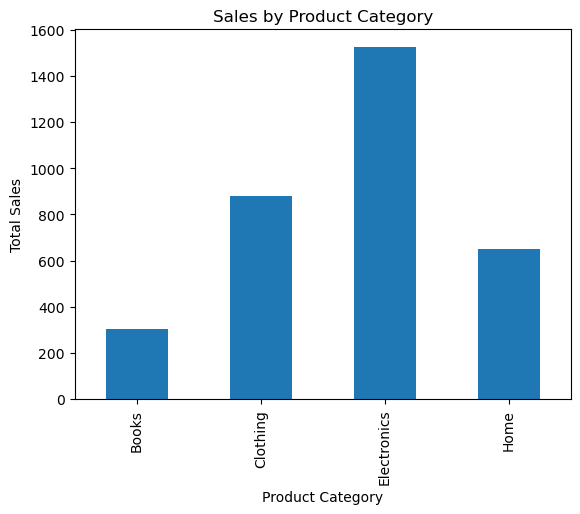

In [85]:
# - Bar chart: Sales by Product Category

sales_by_category = df1.groupby("product_category")["net_amount"].sum()

sales_by_category.plot(kind="bar")
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

In [13]:
df1['payment_method'].value_counts()

payment_method
Credit Card    16
PayPal          8
Debit Card      5
USA             1
Name: count, dtype: int64

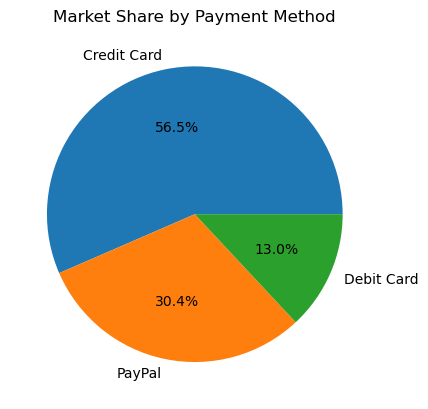

In [70]:
# - Pie chart: Market share by payment method

payment_counts = df1['payment_method'].value_counts()
payment_counts.plot(
    kind ="pie",
    autopct="%1.1f%%"
)
plt.title("Market Share by Payment Method")
plt.ylabel("")
plt.show()

In [93]:
df1['payment_method'].value_counts()

payment_method
Credit Card    13
PayPal          7
Debit Card      3
Name: count, dtype: Int64

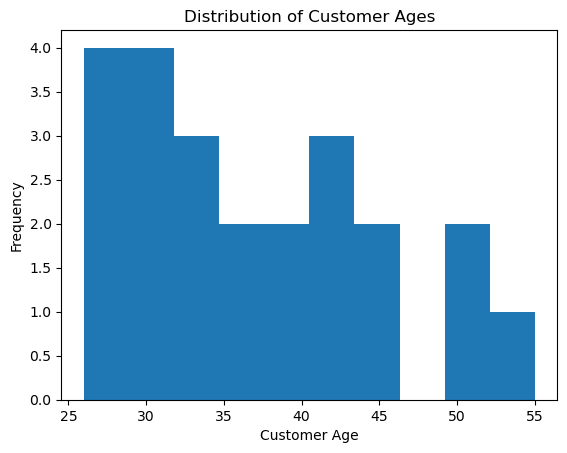

In [94]:
# Histogram: Distribution of customer ages

plt.hist(df1["customer_age"], bins=10)
plt.title("Distribution of Customer Ages")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.show()

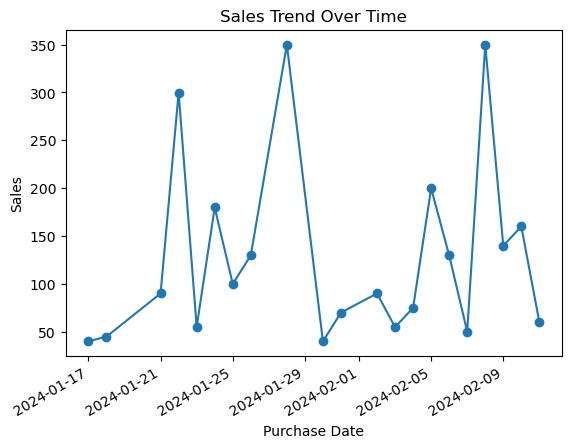

In [151]:
# Line plot: Sales trend over time

sales_trend = df1.groupby("purchase_date")["net_amount"].sum()

sales_trend.plot(kind="line", marker="o")
plt.title("Sales Trend Over Time")
plt.xlabel("Purchase Date")
plt.ylabel("Sales")
plt.show()

In [152]:
sales_trend = df1.groupby("purchase_date")["net_amount"].sum()

In [154]:
sales_trend

purchase_date
2024-01-17     39.98
2024-01-18     44.85
2024-01-21     89.99
2024-01-22    299.98
2024-01-23     55.00
2024-01-24    179.85
2024-01-25     99.94
2024-01-26    129.74
2024-01-28    349.99
2024-01-30     39.89
2024-01-31     69.98
2024-02-02     89.99
2024-02-03     54.80
2024-02-04     74.97
2024-02-05    199.89
2024-02-06    129.74
2024-02-07     49.99
2024-02-08    349.94
2024-02-09    139.83
2024-02-10    159.99
2024-02-11     59.99
Name: net_amount, dtype: float64

In [ ]:
# Box plot: Order value by product category

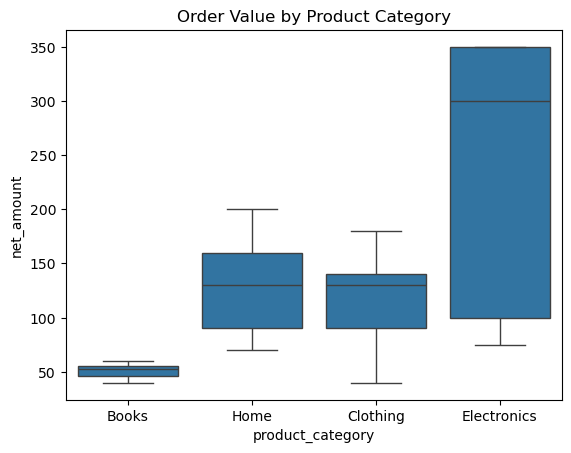

In [157]:
sns.boxplot(
    x="product_category",
    y="net_amount",
    data=df1
)

plt.title("Order Value by Product Category")
plt.show()

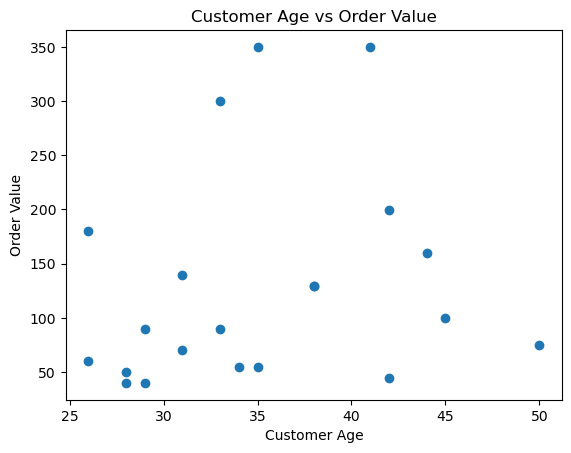

In [159]:
# Scatter plot: Customer age vs. order value

plt.scatter(
    df1["customer_age"],
    df1["net_amount"]
)

plt.title("Customer Age vs Order Value")
plt.xlabel("Customer Age")
plt.ylabel("Order Value")
plt.show()

## **Phase 6: Export Clean Data**

In [192]:
# Save the cleaned and processed dataset to a new CSV file: `cleaned_sales_data.csv`

df1.to_csv("Cleaned_sales_data.csv",index = False)

In [193]:
# 💡 Check Where It Saved

import os
print(os.getcwd())

C:\Users\Rupali


In [198]:
with open("summary_report.txt",'w') as f :
    f.write("===== SALES DATA ANALYSIS REPORT =====\n\n")

    f.write("***BASIC INFORMATION***")
    f.write(f"Total Transactions : {len(df1)}\n")
    f.write(f"Unique Customers : {df1["customer_id"].nunique()}\n\n")

    f.write("***REVENUE DETAILS***\n")
    f.write(f"Total Revenue :{df1["net_amount"].sum()}\n")
    f.write(f"Average Order Value : {df1["net_amount"].mean()}\n\n")

    f.write("***PRODUCT INSIGHTS***\n")
    f.write(f"Top Category :{df1.groupby("product_category")["net_amount"].sum().idxmax()}\n")
    f.write(f"Most Sold Product :{df1.groupby("product_name")["quantity"].sum().idxmax()}\n\n")

    f.write("***PAYMENT INSIGTHS***\n")
    f.write(f"Most Used Method : {df1["payment_method"].value_counts().idxmax()}\n\n")

    f.write("***CUSTOMER DETAILS***\n")
    f.write(f"Average Age : {df1["customer_age"].mean()}\n")
    repeat_customers = (df1["customer_id"].value_counts()>=2).sum()
    f.write(f"Repeat Customers :{repeat_customers}\n\n")


    f.write("***DATE RANGE***\n")
    f.write(f"From :{df1["purchase_date"].min()}\n")
    f.write(f"To : {df1["purchase_date"].max()}\n")


print("REPORT SAVED AS 'summary_report.txt'")
    




REPORT SAVED AS 'summary_report.txt'


In [199]:
import os
print(os.getcwd())

C:\Users\Rupali
